In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import files


uploaded = files.upload()

data = pd.read_csv("laptop_price.csv", encoding='ISO-8859-1')


data.head()

Saving laptop_price.csv to laptop_price.csv


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [3]:
import matplotlib.pyplot as plt

# Function to remove outliers using IQR
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

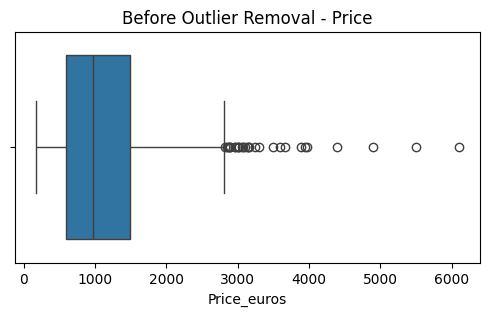

In [5]:
import seaborn as sns
# Before Removal
plt.figure(figsize=(6,3))
sns.boxplot(x=data["Price_euros"])
plt.title("Before Outlier Removal - Price")
plt.show()

In [6]:
# Outlier Removal
cleaned_data = remove_outliers(data, "Price_euros")

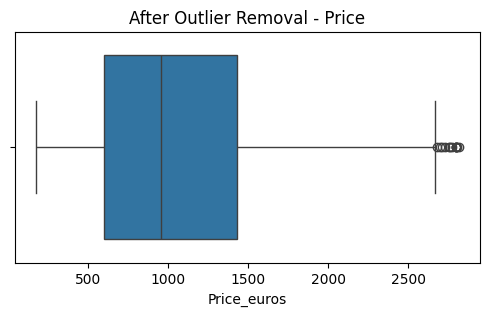

Before: 1303 After: 1274


In [7]:
# After Removal
plt.figure(figsize=(6,3))
sns.boxplot(x=cleaned_data["Price_euros"])
plt.title("After Outlier Removal - Price")
plt.show()

print("Before:", len(data), "After:", len(cleaned_data))